## 1.0) Setup

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.io import decode_image

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

## 2.0) Dataset

In [ ]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

validation_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

print('Training:',len(training_data))
print('Validation + Testing:', len(validation_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.94MB/s]

Training: 60000
Validation + Testing: 10000


## 2.1) Validation-Test split

In [ ]:
from torch.utils.data import random_split

split_generator = torch.Generator().manual_seed(31)

validation_data, testing_data = random_split(validation_data, [5000,5000], generator=split_generator)

print('Validation:', len(validation_data))
print('Testing:', len(testing_data))

Validation: 5000
Testing: 5000


## 2.2) Dataset overview

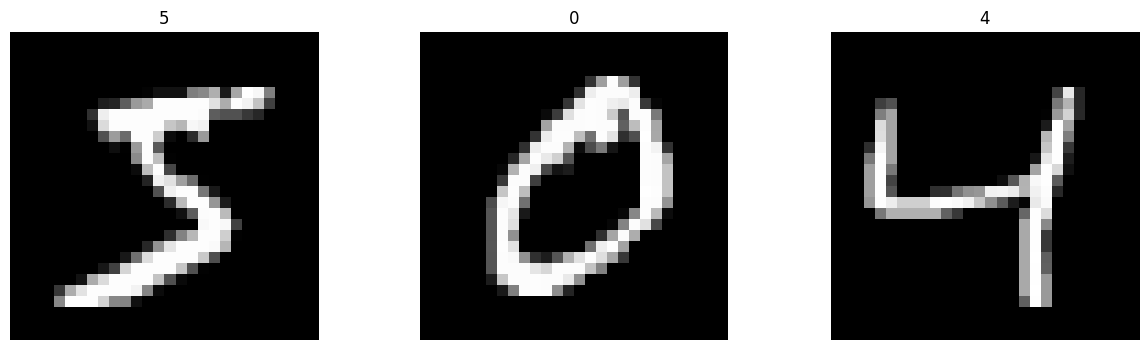

Tamanho da imagem: torch.Size([1, 28, 28])


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
  img, label = training_data[i]
  axes[i].imshow(img.permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")
  axes[i].set_title(label)

plt.show()

print('Tamanho da imagem:',img.shape)

## 2.3) Dataloaders

In [ ]:
training_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=64, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=64, shuffle=True)

## 3.0) Architecture

In [ ]:
import torch.nn.functional as F

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # 1st convolutional layer
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 2nd convolutional layer
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        # Flatten layer
        self.flatten = nn.Flatten()
        # Fully connected layer
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(16*7*7, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## 3.1) Training

In [ ]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_loss = float('inf')
stop = 0
for epoch in range(50):
  model.train()
  print(f'Época {epoch+1}/50...')
  for i, (X, y) in enumerate(training_dataloader):
      if i % 100 == 0:
        print(f'  Batch {i+1}/{len(training_dataloader)+1}...')
      X, y = X.to(device), y.to(device)

      # Compute prediction error
      pred = model(X)
      loss = loss_fn(pred, y)

      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

  model.eval()
  val_loss = 0
  acc = 0
  with torch.no_grad():
    print(f'  Validação...')
    for X, y in validation_dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X)
      loss = loss_fn(pred, y)

      val_loss += loss.item()
      acc += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss = val_loss / len(validation_dataloader)
    acc = acc / len(validation_data)
    print(f'  Acurácia: {(acc*100):.2f}, Validation loss: {val_loss}')
    if val_loss < best_loss:
      best_loss = val_loss
      stop = 0
    else:
      stop += 1
      if stop == 5:
        break

Época 1/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.30, Validation loss: 0.05039239396588712
Época 2/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.24, Validation loss: 0.045092280290997294
Época 3/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.52, Validation loss: 0.04658769552678436
Época 4/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939.

## 4.0) Evaluation on Test set

In [ ]:
model.eval()
with torch.no_grad():
  acc = 0
  for X,y in testing_dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    acc += (pred.argmax(1) == y).type(torch.float).sum().item()

  acc = acc / len(testing_data)
  print(f'Acurácia: {(acc*100):.2f}')

Acurácia: 99.16
